In [1]:
# %%capture cap
!pip install -qq ipywidgets
!pip install -qq autogluon scikit-learn==1.5.2
!apt-get install -qq -y graphviz graphviz-dev && pip install -q pydot
!pip install -qq pygraphviz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 7.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 101.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.1/225.1 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 454.9/454.9 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 487.3/487.3 kB 24.9 MB/s eta 0:0

In [2]:
import torch
import os
import pydot

import random
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from time import time, sleep
from itertools import combinations

from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

## -- Set Global Seed --
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

pd.set_option('display.max_columns', 500)
plt.style.use("ggplot")

## -- Ansi color codes --
COLOR = '\033[32m'
RESET = '\033[0m'

print("Packages import succesful!")

Packages import succesful!


In [3]:
### Load Data ###
PATH = "/kaggle/input/playground-series-s6e1/"
submit = pd.read_csv(PATH+"sample_submission.csv")

list_of_targets = [
    'age',
    'study_hours',
    'class_attendance',
    'sleep_hours',
    'gender',
    'course',
    'internet_access',
    'sleep_quality',
    'study_method',
    'facility_rating',
    'exam_difficulty',
]

TARGET = list_of_targets[6]

train = pd.read_csv(PATH+"train.csv", index_col='id').drop(['exam_score'], axis=1)
test = pd.read_csv(PATH+"test.csv", index_col='id')

NUMS = test.select_dtypes(include='number').columns.tolist()
CATS = test.select_dtypes(exclude='number').columns.tolist()
BASE = NUMS + CATS

ORIG_PATH = '/kaggle/input/exam-score-prediction-dataset/'
orig = pd.read_csv(ORIG_PATH+'Exam_Score_Prediction.csv')[BASE]

for (name, df) in dict(Train=train, Test=test, Orignal=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (630000, 11)
Test shape: (270000, 11)
Orignal shape: (20000, 11)

Total Numerical: 4
Total Categorical: 7
Total base features: 11


In [4]:
orig.head()

,age,study_hours,class_attendance,sleep_hours,gender,course,internet_access,sleep_quality,study_method,facility_rating,exam_difficulty
0,17,2.78,92.9,7.4,male,diploma,yes,poor,coaching,low,hard
1,23,3.37,64.8,4.6,other,bca,yes,average,online videos,medium,moderate
2,22,7.88,76.8,8.5,male,b.sc,yes,poor,coaching,high,moderate
3,20,0.67,48.4,5.8,other,diploma,yes,average,online videos,low,moderate
4,20,0.89,71.6,9.8,female,diploma,yes,poor,coaching,low,moderate


In [5]:
# orig[TARGET].nunique()

In [6]:
MODELS_PATH = "/kaggle/working/AG_models/"
# !rm -r {MODELS_PATH}

In [7]:
from autogluon.tabular import TabularPredictor

In [8]:
TIME_1_HR = 3600
predictor = TabularPredictor(
                label = TARGET,
         # problem_type = "regression",
          # eval_metric = "roc_auc",
                 path = MODELS_PATH,
    ).fit(
                   train_data = orig,
                      presets = "best",
                # num_bag_folds = 8,
                   # auto_stack = False,
             dynamic_stacking = False,
             num_stack_levels = 1,
                   time_limit = TIME_1_HR/2,
                 # num_bag_sets = 2,
                  # ag_args_fit = {'num_cpus': os.cpu_count()},
) 

Preset alias specified: 'best' maps to 'best_quality'.
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.11.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Sat Sep 27 10:16:09 UTC 2025
CPU Count:          4
Memory Avail:       29.90 GB / 31.35 GB (95.4%)
Disk Space Avail:   19.50 GB / 19.52 GB (99.9%)
Presets specified: ['best']
Using hyperparameters preset: hyperparameters='zeroshot'
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Beginning AutoGluon training ... Time limit = 1800s
AutoGluon will save models to "/kaggle/working/AG_models"
Train Data Rows:    20000
Train Data Columns: 10
Label Column:       internet_access
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  ['yes', 'no']
	If 'binary' is not the correct problem_type, please manually speci

In [9]:
## -- Get Summary -- 
print(f"-> Total models : {len(predictor.model_names())}")
print(f"-> Best model   : {predictor.model_best}") 

## -- Observe RUN 1 RESULTS -- 
leaderboard = predictor.leaderboard(silent=True)
leaderboard.style.background_gradient(subset=["score_val"], cmap="Spectral")

-> Total models : 49
-> Best model   : WeightedEnsemble_L2


,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,XGBoost_BAG_L1,0.849650,accuracy,0.252983,10.546870,0.252983,10.546870,1,True,9
1,WeightedEnsemble_L3,0.849650,accuracy,0.255308,12.781411,0.002326,2.234541,3,True,49
2,WeightedEnsemble_L2,0.849650,accuracy,0.255394,12.359943,0.002412,1.813073,2,True,33
3,NeuralNetTorch_r79_BAG_L2,0.849650,accuracy,16.173423,1201.293694,0.581747,111.420962,2,True,46
4,XGBoost_BAG_L2,0.849550,accuracy,15.837900,1110.273561,0.246224,20.400829,2,True,42
5,NeuralNetFastAI_BAG_L1,0.849500,accuracy,0.690724,76.528718,0.690724,76.528718,1,True,8
6,CatBoost_r9_BAG_L1,0.849450,accuracy,0.096133,24.664352,0.096133,24.664352,1,True,16
7,XGBoost_r89_BAG_L1,0.849450,accuracy,0.187430,10.337815,0.187430,10.337815,1,True,27
8,LightGBM_BAG_L2,0.849450,accuracy,15.741810,1106.058548,0.150134,16.185816,2,True,35
9,NeuralNetTorch_BAG_L2,0.849450,accuracy,16.192662,1166.484854,0.600986,76.612122,2,True,43


In [10]:
## -- RUN 2: Use original data as extra learning input --
# predictor.fit_pseudolabel(
#                 orig,
#                 use_ensemble = True,
#                 fit_ensemble = True,
#                 time_limit   = 3600*5,
#                 ag_args_fit  = {'num_cpus': os.cpu_count() - 1},
# )

In [11]:
## -- Get Summary -- 
# print(f"""
#     # {'█'*5}| Total models : {len(predictor.model_names())}
#     # {'█'*5}| Best model   : {predictor.model_best}
#         """)

# # -- Observe RUN 2 RESULTS --
# leaderboard = predictor.leaderboard(silent=True)
# display(leaderboard.style.background_gradient(subset=["score_val"], cmap="Spectral"))

In [12]:
## -- Create folder directory to save predictions --
SAVE_PATH = '/kaggle/working/AG_preds/'
!mkdir {SAVE_PATH}

In [13]:
%%time
## -- Predictions for MULTICLASS FEATURE --
TRAIN_preds = predictor.predict(train).to_frame()
TRAIN_preds.to_parquet(f"{SAVE_PATH}train_AG_{TARGET}.parquet", index=False)
print(f" - {len(TRAIN_preds)} Train predictions saved!")

TEST_preds = predictor.predict(test).to_frame()
TEST_preds.to_parquet(f"{SAVE_PATH}test_AG_{TARGET}.parquet", index=False)
print(f" - {len(TEST_preds)} Test predictions saved!")

display(TRAIN_preds.head())
display(TEST_preds.head())

 - 630000 Train predictions saved!
 - 270000 Test predictions saved!


,internet_access
id,
0,yes
1,yes
2,yes
3,yes
4,yes


,internet_access
id,
630000,yes
630001,yes
630002,yes
630003,yes
630004,yes


CPU times: user 46.4 s, sys: 2.08 s, total: 48.5 s
Wall time: 36.5 s


In [14]:
# ## -- Predictions for REGRESSION FEATURE --
# TRAIN_preds = predictor.predict(train).to_frame()
# TRAIN_preds.to_parquet(f"{SAVE_PATH}train_AG_on_{TARGET}.parquet", TRAIN_preds)
# print(f" - {len(TRAIN_preds)} Train predictions saved!")

# TEST_preds = predictor.predict(test).to_frame()
# TEST_preds.to_parquet(f"{SAVE_PATH}test_AG_on_{TARGET}.parquet", index=False)
# print(f" - {len(TEST_preds)} Test predictions saved!")

# display(TRAIN_preds.head())
# display(TEST_preds.head())

In [15]:
# %%time
# ## -- Predictions for BINARY FEATURE --
# TRAIN_preds = predictor.predict_proba(train, as_multiclass=False, as_pandas=False)
# np.save(f"{SAVE_PATH}train_AG_on_{TARGET}.npy", TRAIN_preds)
# print(f" - {len(TRAIN_preds)} Train predictions saved!")

# TEST_preds = predictor.predict_proba(test, as_multiclass=False, as_pandas=False)
# np.save(f"{SAVE_PATH}test_AG_on_{TARGET}.npy", TEST_preds)
# print(f" - {len(TEST_preds)} Test predictions saved!")

# np.vstack((TRAIN_preds[:10], TEST_preds[:10]))

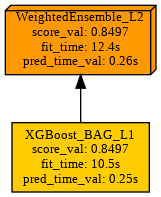

In [16]:
predictor.plot_ensemble_model(filename='ensemble_model.png')
display(Image(f'{MODELS_PATH}ensemble_model.png'))

In [17]:
# !zip -r /kaggle/working/AG_accident_models /kaggle/working/AG_accident_models.zip
# !zip -r {FOLDER}{NAME_EXT}.zip /kaggle/working/{FOLDER}{NAME_EXT}

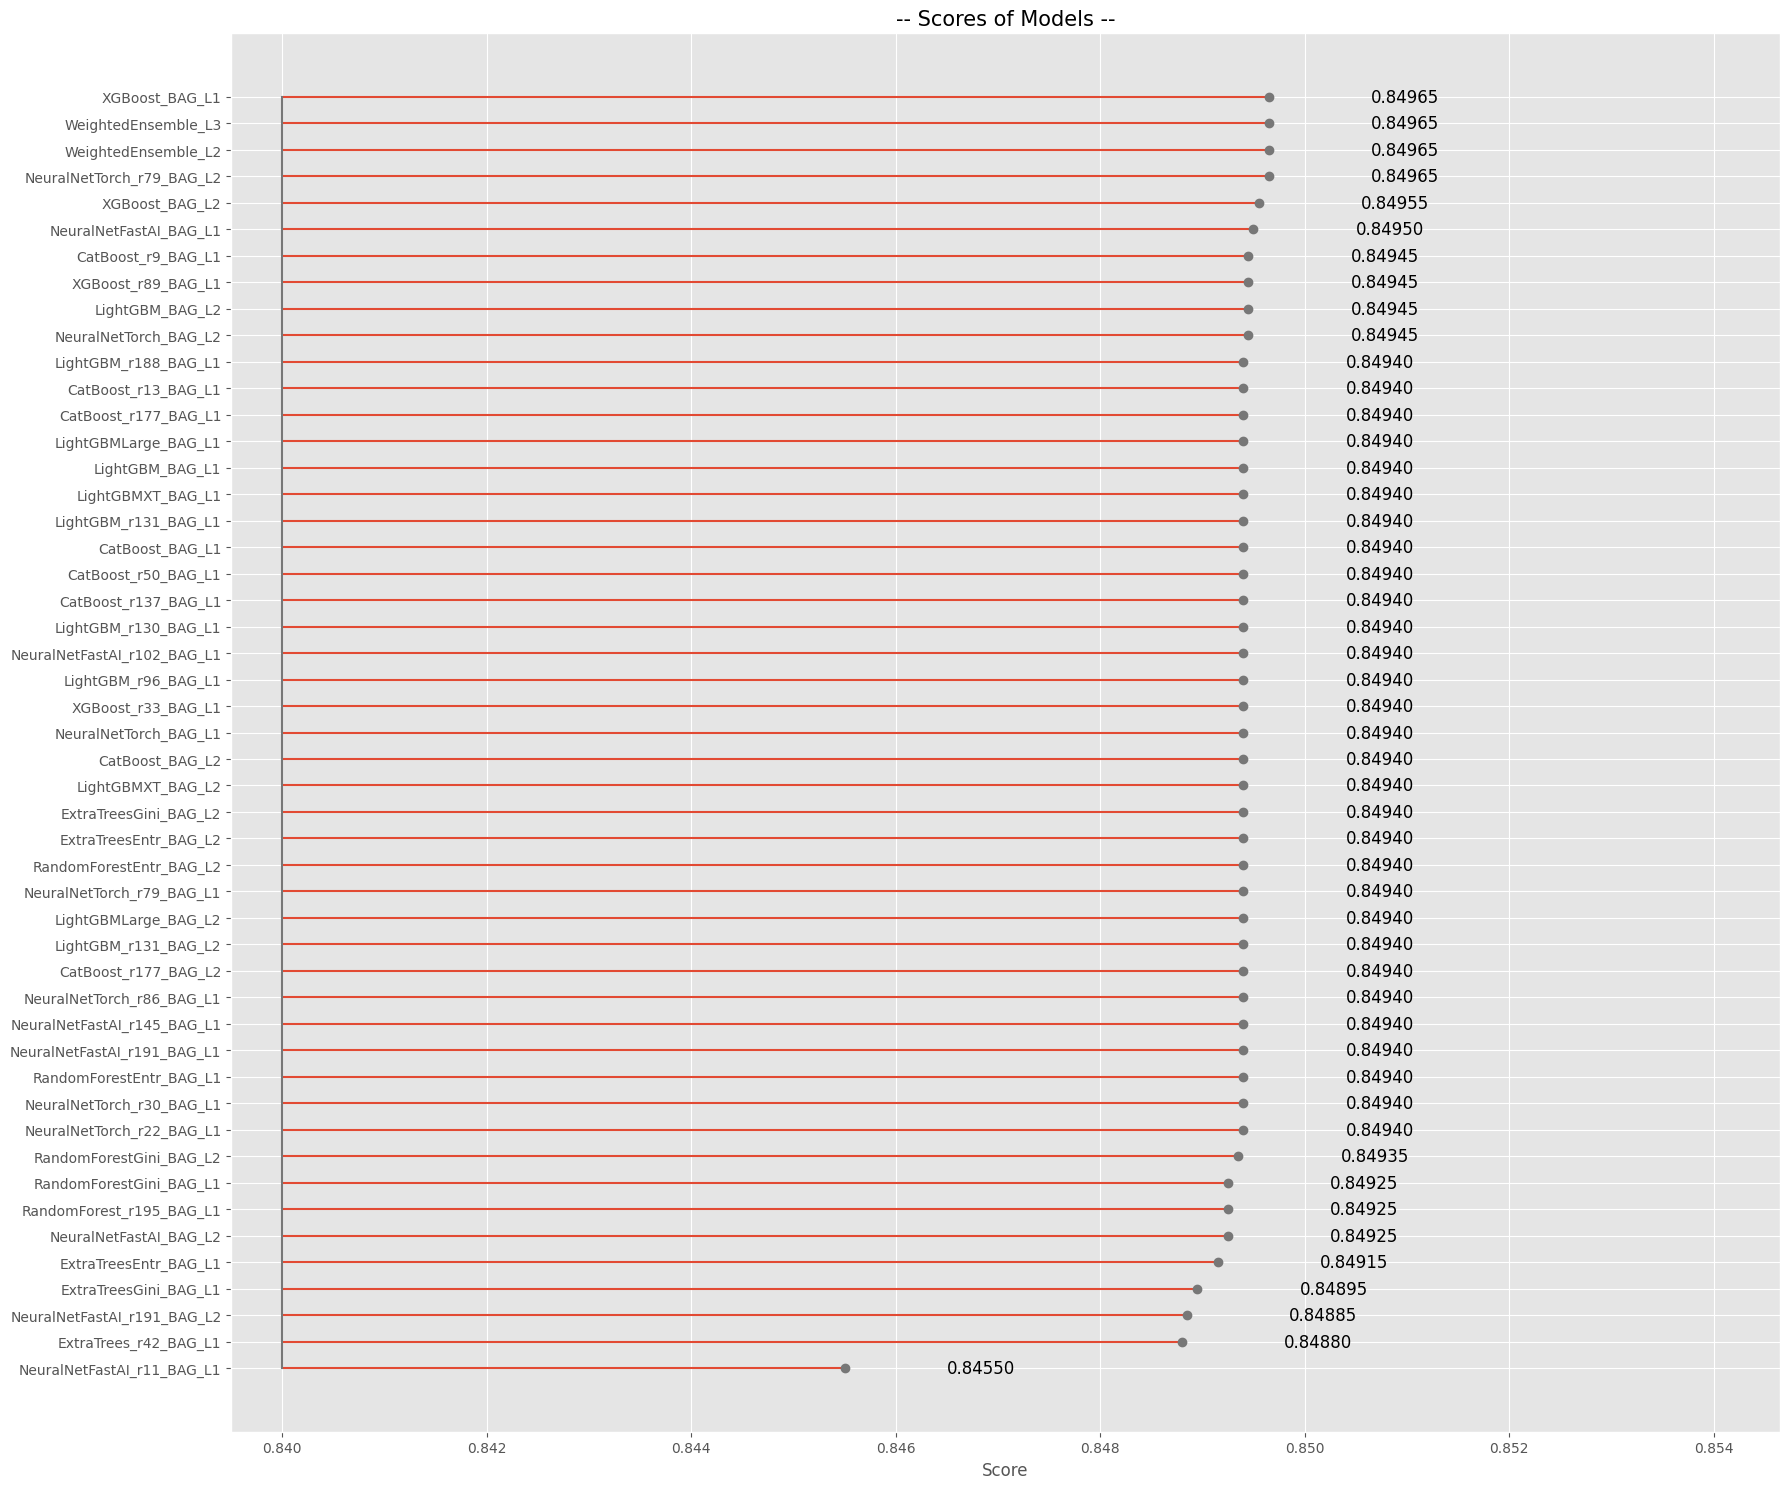

In [18]:
## -- Extract model scores --
result_ = dict(zip(leaderboard['model'], leaderboard['score_val']))
result_df = pd.DataFrame.from_dict(result_, orient='index').sort_values(0)

max_score = result_df.max().item()
min_score = result_df.min().item()

## -- PLOT MODELS & SCORES --
plt.figure(figsize=(18, 15))
plt.stem(
    result_df.index,
    result_df[0],
    orientation = 'horizontal',
    bottom = min_score - 0.0055,
    markerfmt = 'C3o'
)
plt.xlim(min_score - 0.006, max_score + 0.005)
plt.xlabel('Score')
plt.title('-- Scores of Models --', fontsize=15)

for i, value in enumerate(result_df[0]):
    plt.text(value+1e-3, i, f'{abs(value):.5f}', ha='left', va='center', fontdict=dict(size=12))

plt.grid(True, axis='x')
plt.tight_layout()
plt.show()

In [19]:
# predictor.model_names()

In [20]:
# ## -- Permutation Feature Importances --
# feat_imp = predictor.feature_importance(
#                         data = X_test,
#                         # time_limit = 3600,
#                         # model = 'LightGBM_BAG_L1',
#                         # features = None,
#                         # feature_stage = 'transformed',
#                         # subsample_size = 5000,
#                         # num_shuffle_sets = 10,
#                         # include_confidence_band = True,
#                         confidence_level = 0.95,
#                         # silent = False
# ) 

# feat_imp.style.background_gradient(subset=["importance"], cmap="Spectral")

In [21]:
# plt.figure(figsize=(18, 35))
# sns.barplot(data=feat_imp, y=feat_imp.index, x=feat_imp.importance)
# plt.tick_params(axis='y', which='major', labelcolor='r')
# plt.title("Top Features by Permutation")
# plt.tight_layout()
# plt.show()

In [22]:
## -- OPTIONAL: Remove stored files --
!rm -r {MODELS_PATH}

In [23]:
print(f"""
{'-'*48}
{'█'*5} | - AUTOGLUON NOTEBOOK COMPLETE! - | {'█'*5}
{'-'*48}
""")


------------------------------------------------
█████ | - AUTOGLUON NOTEBOOK COMPLETE! - | █████
------------------------------------------------

